In [2]:
import os
from functools import lru_cache

import pandas as pd
import numpy as np
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt
from astropy.io import fits

In [3]:
# SALT3 template0 (rest-frame SED grid: phase, wavelength [A], flux)
SALT3_MODEL_DIR = os.path.join(os.environ["SNDATA_ROOT"], "models", "SALT3", "SALT3.P22-NIR")
SALT3_TEMPLATE0_FILE = os.path.join(SALT3_MODEL_DIR, "salt3_template_0.dat.gz")

# Roman filter transmissions: nominal + per-SCA "shifted" (chromatic) bandpasses
ROMAN_FILTERS_DIR = "/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/ROMAN_FILTERS"

In [4]:
@lru_cache(maxsize=None)
def load_salt3_template(component):
    """Load salt3_template_{component}.dat.gz (component 0 or 1) into (phases, waves, flux_grid)."""
    path = os.path.join(SALT3_MODEL_DIR, f"salt3_template_{component}.dat.gz")
    phase, wave, flux = np.loadtxt(path, unpack=True)
    phases = np.unique(phase)
    waves = np.unique(wave)
    return phases, waves, flux.reshape(len(phases), len(waves))


def sed_components_at_epoch(epoch):
    """Rest-frame (wavelength [A], M0, M1) of the SALT3 templates at the given phase (days from peak)."""
    phases0, waves0, grid0 = load_salt3_template(0)
    phases1, waves1, grid1 = load_salt3_template(1)
    m0 = RectBivariateSpline(phases0, waves0, grid0, kx=1, ky=1)(epoch, waves0)[0]
    m1 = RectBivariateSpline(phases1, waves1, grid1, kx=1, ky=1)(epoch, waves1)[0]
    return waves0, m0, m1

In [5]:
def _parse_salt3_info_colorlaw(info_path):
    """Parse RESTLAMBDA_RANGE/COLORCOR_PARAMS out of a SALT3.INFO file."""
    with open(info_path) as f:
        for line in f:
            if line.strip().startswith("COLORCOR_PARAMS:"):
                vals = line.split(":", 1)[1].split()
                wave_lo, wave_hi, n = float(vals[0]), float(vals[1]), int(vals[2])
                coeffs = np.array([float(v) for v in vals[3:3 + n]])
                return wave_lo, wave_hi, coeffs
    raise ValueError(f"COLORCOR_PARAMS not found in {info_path}")


SALT3_INFO_FILE = os.path.join(SALT3_MODEL_DIR, "SALT3.INFO")
CL_WAVE_LO, CL_WAVE_HI, CL_COEFFS = _parse_salt3_info_colorlaw(SALT3_INFO_FILE)

# SALT2/SALT3 color law is defined in reduced wavelength l = (wave - B)/(V - B)
SALT2_B_WAVELENGTH = 4302.57
SALT2_V_WAVELENGTH = 5428.55

In [6]:
def _color_law_poly(l, coeffs):
    """SALT2/SALT3 color-law polynomial P(l): P(0)=0, P(1)=-1 by construction."""
    val = -l
    for i, p in enumerate(coeffs):
        val = val + p * (l - l ** (i + 2))
    return val


def _color_law_poly_deriv(l, coeffs):
    d = -1.0
    for i, p in enumerate(coeffs):
        d = d + p * (1 - (i + 2) * l ** (i + 1))
    return d


def salt3_color_law(wave):
    """
    SALT2/SALT3 color law CL(wave). The color-dependent flux factor is
    10 ** (-0.4 * c * CL(wave)). Linearly extrapolated outside
    [CL_WAVE_LO, CL_WAVE_HI] using the polynomial's value/derivative at the boundary.
    """
    wave = np.atleast_1d(np.asarray(wave, dtype=float))
    l = (wave - SALT2_B_WAVELENGTH) / (SALT2_V_WAVELENGTH - SALT2_B_WAVELENGTH)
    l_lo = (CL_WAVE_LO - SALT2_B_WAVELENGTH) / (SALT2_V_WAVELENGTH - SALT2_B_WAVELENGTH)
    l_hi = (CL_WAVE_HI - SALT2_B_WAVELENGTH) / (SALT2_V_WAVELENGTH - SALT2_B_WAVELENGTH)
    p_lo, p_hi = _color_law_poly(l_lo, CL_COEFFS), _color_law_poly(l_hi, CL_COEFFS)
    dp_lo, dp_hi = _color_law_poly_deriv(l_lo, CL_COEFFS), _color_law_poly_deriv(l_hi, CL_COEFFS)

    return np.where(
        l < l_lo, p_lo + dp_lo * (l - l_lo),
        np.where(l > l_hi, p_hi + dp_hi * (l - l_hi), _color_law_poly(l, CL_COEFFS)),
    )


def salt3_flux(epoch, x0=1.0, x1=0.0, c=0.0):
    """Rest-frame SALT3 SED: x0 * (M0 + x1*M1) * 10**(-0.4*c*CL(wave))."""
    wave, m0, m1 = sed_components_at_epoch(epoch)
    flux = x0 * (m0 + x1 * m1) * 10.0 ** (-0.4 * c * salt3_color_law(wave))
    return wave, flux

In [7]:
from scipy.optimize import least_squares


def fit_x1_color(spectrum_wave, spectrum_flux, epoch, x0_guess=1.0):
    """
    Fit (x0, x1, c) of the SALT3 model to a rest-frame flux-calibrated spectrum at `epoch`.

    spectrum_wave, spectrum_flux : rest-frame wavelength [A] and flux density of the SN spectrum.
    epoch : rest-frame phase (days from peak) the spectrum was taken at.
    """
    model_wave, m0, m1 = sed_components_at_epoch(epoch)
    m0_on_spec = np.interp(spectrum_wave, model_wave, m0)
    m1_on_spec = np.interp(spectrum_wave, model_wave, m1)
    cl_on_spec = salt3_color_law(spectrum_wave)

    def residuals(params):
        x0, x1, c = params
        model = x0 * (m0_on_spec + x1 * m1_on_spec) * 10.0 ** (-0.4 * c * cl_on_spec)
        return model - spectrum_flux

    result = least_squares(residuals, x0=[x0_guess, 0.0, 0.0])
    x0, x1, c = result.x
    return {"x0": x0, "x1": x1, "c": c, "success": result.success, "cost": result.cost}

In [8]:
def get_transmission_file(band, sca=None):
    """
    Path to a Roman transmission file for `band` (e.g. "F062", "F087", "F106",
    "F129", "F158", "F184", "W146", "F213").

    sca=None -> the nominal/reference bandpass: ROMAN_FILTERS/{band}/ROMAN_{band}.dat
                (falls back to ROMAN_FILTERS/ROMAN_{band}.dat for bands with no per-SCA files).
    sca=<int in 1..18> -> the SCA-specific "shifted" (chromatic) bandpass:
                ROMAN_FILTERS/{band}/ROMAN_{band}_shifted_{sca}.dat
    """
    band_dir = os.path.join(ROMAN_FILTERS_DIR, band)
    if sca is None:
        in_band_dir = os.path.join(band_dir, f"ROMAN_{band}.dat")
        return in_band_dir if os.path.exists(in_band_dir) else os.path.join(ROMAN_FILTERS_DIR, f"ROMAN_{band}.dat")
    return os.path.join(band_dir, f"ROMAN_{band}_shifted_{sca}.dat")


def load_transmission(path):
    """Load a transmission file: two columns, wavelength [A] and throughput (0-1).

    Header lines are skipped whether or not they start with '#' (nominal files are
    inconsistent about this), so parsing just skips any line that isn't two floats.
    """
    wave, thru = [], []
    with open(path) as f:
        for line in f:
            parts = line.split()
            if len(parts) != 2:
                continue
            try:
                w, t = float(parts[0]), float(parts[1])
            except ValueError:
                continue
            wave.append(w)
            thru.append(t)
    return np.array(wave), np.array(thru)

In [9]:
def synphot_mag(wave, flux, band_wave, band_thru):
    """
    Synthetic magnitude of an SED (wave [A], flux [erg/s/cm2/A]) through a bandpass.

    Only the *difference* between two such magnitudes is used in `handshake`, so any
    fixed zeropoint convention works as long as it's applied consistently.
    """
    thru_on_sed_grid = np.interp(wave, band_wave, band_thru, left=0.0, right=0.0)
    bandflux = np.trapezoid(flux * thru_on_sed_grid * wave, wave)
    return -2.5 * np.log10(bandflux)

In [10]:
def handshake(band, sca, epoch, z, x1=0.0, c=0.0):
    """Takes in given parameters and returns magcorrection.

    correction = mag(through SCA-specific transmission) - mag(through nominal transmission),
    evaluated on the SALT3 SED (M0 + x1*M1, color law c) at `epoch` (days from peak),
    redshifted to `z`.
    """
    rest_wave, rest_flux = salt3_flux(epoch, x1=x1, c=c)

    obs_wave = rest_wave * (1.0 + z)
    obs_flux = rest_flux / (1.0 + z)  # cosmological surface-brightness dimming

    nominal_wave, nominal_thru = load_transmission(get_transmission_file(band, sca=None))
    chromatic_wave, chromatic_thru = load_transmission(get_transmission_file(band, sca=sca))

    mag_nominal = synphot_mag(obs_wave, obs_flux, nominal_wave, nominal_thru)
    mag_chromatic = synphot_mag(obs_wave, obs_flux, chromatic_wave, chromatic_thru)

    return mag_chromatic - mag_nominal

In [11]:
handshake("F129", 10, epoch=+10.0, z=1)

np.float64(0.001403275575867724)

In [12]:
# Fit SN with nominal filters warp with x1, c
# x1 and c models, add ons to M0

# Sanity check: use template0 itself (x1=0, c=0) as a mock "observed" spectrum at a given
# epoch, and confirm fit_x1_color recovers x0=1, x1=0, c=0.
_test_epoch = 0.0
_test_wave, _test_m0, _ = sed_components_at_epoch(_test_epoch)
fit_x1_color(_test_wave, _test_m0, _test_epoch)

{'x0': np.float64(1.0),
 'x1': np.float64(0.0),
 'c': np.float64(0.0),
 'success': True,
 'cost': np.float64(0.0)}

In [13]:
# Full pipeline: fit (x1, c) from a spectrum, then feed them into the chromatic correction.
# Swap _test_wave/_test_m0/_test_epoch above for a real observed spectrum + its phase.
_fit = fit_x1_color(_test_wave, _test_m0, _test_epoch)
handshake("F129", 10, epoch=_test_epoch, z=1.0, x1=_fit["x1"], c=_fit["c"])

np.float64(0.0016420042698150894)

In [14]:
handshake("F184", 10, epoch=1, z=2.0, x1=_fit["x1"], c=_fit["c"])

np.float64(0.001004214292972705)

In [15]:
# Read in sim outputs

In [16]:
DATA_DIR = "/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker"


def load_lcplot(path):
    """Load a SNANA LCPLOT(text:csv) table into a DataFrame."""
    df = pd.read_csv(path, skipinitialspace=True)
    df.columns = [c.strip() for c in df.columns]
    return df


lcplot_s1 = load_lcplot(os.path.join(DATA_DIR, "CODETEST_HANDSHAKER_S1.LCPLOT.TEXT"))
lcplot_s2 = load_lcplot(os.path.join(DATA_DIR, "CODETEST_HANDSHAKER_S2.LCPLOT.TEXT"))

In [17]:
def load_fitres(path):
    """Load a SNANA FITRES text table (VARNAMES:/SN: rows, not plain CSV) into a DataFrame."""
    names, rows = None, []
    with open(path) as f:
        for line in f:
            if line.startswith("VARNAMES:"):
                names = line.split()[1:]
            elif line.startswith("SN:"):
                rows.append(line.split()[1:])
    df = pd.DataFrame(rows, columns=names)
    for col in df.columns:
        converted = pd.to_numeric(df[col], errors="coerce")
        if converted.notna().all():
            df[col] = converted
    return df


fitres_s1 = load_fitres(os.path.join(DATA_DIR, "CODETEST_HANDSHAKER_S1.FITRES.TEXT"))
fitres_s2 = load_fitres(os.path.join(DATA_DIR, "CODETEST_HANDSHAKER_S2.FITRES.TEXT"))

In [18]:
fitres_s2[["CID", "x1", "c", "mB"]].head()

,CID,x1,c,mB
0,1341390,0.37555,0.086097,26.61547
1,136357,0.60081,-0.060991,26.61911
2,1368244,0.75667,0.120720,24.36025
3,716809,0.63488,-0.018616,25.20539
4,2745016,0.57786,0.174840,26.92785


In [19]:
# CID alone isn't a unique key here (many epochs/bands per SN). DATAFLAG also has to be
# part of the key: a handful of epochs have both a DATAFLAG=1 (data) row and a DATAFLAG=0
# (model-grid) row at the exact same MJD/BAND, and merging on (CID, MJD, BAND) alone lets
# a data row in one file spuriously match a model-grid row in the other.
lcplot_data = pd.merge(lcplot_s1, lcplot_s2, on=["CID", "MJD", "BAND", "DATAFLAG"], how="inner", suffixes=("_s1", "_s2"))
lcplot_data["delta_FLUXCAL"] = lcplot_data["FLUXCAL_s2"] - lcplot_data["FLUXCAL_s1"]
lcplot_data["delta_SIM_FLUXCAL"] = lcplot_data["SIM_FLUXCAL_s2"] - lcplot_data["SIM_FLUXCAL_s1"]

In [20]:
fitres_data = pd.merge(fitres_s1, fitres_s2, on="CID", how="inner", suffixes=("_s1", "_s2"))
fitres_data["delta_x1"] = fitres_data["x1_s2"] - fitres_data["x1_s1"]
fitres_data["delta_c"] = fitres_data["c_s2"] - fitres_data["c_s1"]
fitres_data[["CID", "x1_s1", "x1_s2", "delta_x1", "c_s1", "c_s2", "delta_c"]]

/tmp/ipykernel_19635/2580343405.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fitres_data["delta_x1"] = fitres_data["x1_s2"] - fitres_data["x1_s1"]
/tmp/ipykernel_19635/2580343405.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fitres_data["delta_c"] = fitres_data["c_s2"] - fitres_data["c_s1"]


,CID,x1_s1,x1_s2,delta_x1,c_s1,c_s2,delta_c
0,1341390,0.374830,0.375550,0.000720,0.086649,0.086097,-5.515000e-04
1,136357,0.583330,0.600810,0.017480,-0.061135,-0.060991,1.437000e-04
2,1368244,0.758160,0.756670,-0.001490,0.121150,0.120720,-4.300000e-04
3,716809,0.636760,0.634880,-0.001880,-0.018332,-0.018616,-2.831000e-04
4,2745016,0.572660,0.577860,0.005200,0.176300,0.174840,-1.460000e-03
5,1793194,0.272600,0.269410,-0.003190,0.112560,0.113470,9.100000e-04
6,56221,-0.460924,-0.454190,0.006734,0.041568,0.042323,7.554000e-04
7,2765467,0.061331,0.070510,0.009179,-0.001742,-0.002516,-7.736200e-04
8,983926,0.712380,0.711670,-0.000710,0.018150,0.017862,-2.881000e-04
9,2838252,0.900700,0.894880,-0.005820,-0.142362,-0.142444,-8.200000e-05


In [21]:
print(f"delta_x1: mean={fitres_data['delta_x1'].mean():.4f}, std={fitres_data['delta_x1'].std():.4f}")
print(f"delta_c:  mean={fitres_data['delta_c'].mean():.5f}, std={fitres_data['delta_c'].std():.5f}")

# DATAFLAG: 1=>real data, 0=>fit-model curve (dense plotting grid), -1=>data rejected in fit.
real_data = lcplot_data[lcplot_data["DATAFLAG"] == 1]
print(f"\nmatched real-data epochs: {len(real_data)} of {len(lcplot_s1[lcplot_s1.DATAFLAG == 1])}")
real_data[["CID", "MJD", "BAND", "FLUXCAL_s1", "FLUXCAL_s2", "delta_FLUXCAL"]]

delta_x1: mean=0.0045, std=0.0209
delta_c:  mean=-0.00018, std=0.00110

matched real-data epochs: 293 of 293


,CID,MJD,BAND,FLUXCAL_s1,FLUXCAL_s2,delta_FLUXCAL
1,1341390,62483.0781,t,35.571,35.571,0.000
2,1341390,62563.2891,t,42.401,42.401,0.000
3,1341390,62573.9766,t,21.692,21.692,0.000
5,1341390,62491.4180,u,16.660,16.434,-0.226
6,1341390,62526.9805,u,172.360,171.490,-0.870
...,...,...,...,...,...,...
4516,2745016,62683.1484,O,164.390,164.390,0.000
4517,2745016,62740.5508,O,68.343,68.244,-0.099
4518,2745016,62683.1328,P,153.600,153.600,0.000
4519,2745016,62759.4844,P,77.583,77.264,-0.319


In [22]:
# Compare S1-vs-S2 delta to the theoretical handshake() prediction.
#
# The band-chars in FITRES/LCPLOT ("a", "b", ... "0", "1") don't map cleanly by index to
# ROMAN_FILTERS/*_shifted_N.dat (checked: transmission centroids don't line up 1:1 with
# SCA number). Instead, use the *exact* per-band-char transmission curves embedded in the
# two kcor files actually used by the fits: roman_nominal.fits (S1) and roman_shifts.fits (S2).
KCOR_NOMINAL_FILE = "/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/inputs/roman_nominal.fits"
KCOR_SHIFTS_FILE = "/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/inputs/roman_shifts.fits"


def _load_kcor_filtertrans(kcor_path):
    """Read the FilterTrans table of a kcor FITS file into plain numpy arrays."""
    with fits.open(kcor_path) as hdul:
        data = hdul["FilterTrans"].data
        wave = np.array(data["wavelength (A)"], dtype=float)
        cols = {name: np.array(data[name], dtype=float) for name in data.columns.names if name != "wavelength (A)"}
    return wave, cols


@lru_cache(maxsize=None)
def _kcor_filtertrans_cached(kcor_path):
    return _load_kcor_filtertrans(kcor_path)


def load_kcor_transmission(kcor_path, band_char):
    """Transmission curve for a single-char band (e.g. "a", "T") from a kcor FITS file's FilterTrans table."""
    wave, cols = _kcor_filtertrans_cached(kcor_path)
    matches = [name for name in cols if name.endswith(f"/{band_char}")]
    if len(matches) != 1:
        raise ValueError(f"expected exactly one column ending in '/{band_char}' in {kcor_path}, got {matches}")
    return wave, cols[matches[0]]

In [23]:
def handshake_kcor(band_char, epoch, z, x1=0.0, c=0.0):
    """
    Like handshake(), but for a single-char FITRES/LCPLOT band, using the exact
    transmission curves embedded in the S1/S2 kcor files rather than an SCA-numbered
    ROMAN_FILTERS file.

    correction = mag(S2 kcor transmission) - mag(S1 kcor transmission)
    """
    rest_wave, rest_flux = salt3_flux(epoch, x1=x1, c=c)
    obs_wave = rest_wave * (1.0 + z)
    obs_flux = rest_flux / (1.0 + z)

    nominal_wave, nominal_thru = load_kcor_transmission(KCOR_NOMINAL_FILE, band_char)
    shifts_wave, shifts_thru = load_kcor_transmission(KCOR_SHIFTS_FILE, band_char)

    mag_nominal = synphot_mag(obs_wave, obs_flux, nominal_wave, nominal_thru)
    mag_shifts = synphot_mag(obs_wave, obs_flux, shifts_wave, shifts_thru)

    return mag_shifts - mag_nominal

In [24]:
# Per-epoch comparison: empirical delta_mag (from FLUXCAL_s1/s2) vs. handshake_kcor's
# theoretical prediction, using each SN's S1-fitted (x1, c) and zHD, at that epoch's
# rest-frame phase (Trest = Tobs_s1 / (1+z)).
comparison = real_data.copy()
comparison = comparison.join(fitres_s1.set_index("CID")[["zHD", "x1", "c"]], on="CID")
comparison["Trest"] = comparison["Tobs_s1"] / (1.0 + comparison["zHD"])

positive_flux = (comparison["FLUXCAL_s1"] > 0) & (comparison["FLUXCAL_s2"] > 0)
print(f"dropping {(~positive_flux).sum()} of {len(comparison)} epochs with non-positive FLUXCAL (can't take log)")
comparison = comparison[positive_flux]

comparison["empirical_delta_mag"] = -2.5 * np.log10(comparison["FLUXCAL_s2"] / comparison["FLUXCAL_s1"])
comparison["predicted_delta_mag"] = [
    handshake_kcor(row.BAND, row.Trest, row.zHD, x1=row.x1, c=row.c) for row in comparison.itertuples()
]
comparison["residual"] = comparison["empirical_delta_mag"] - comparison["predicted_delta_mag"]

print(f"\nresidual (empirical - predicted): mean={comparison['residual'].mean():.4f}, std={comparison['residual'].std():.4f}")
print(f"correlation: {comparison['empirical_delta_mag'].corr(comparison['predicted_delta_mag']):.3f}")
comparison[["CID", "MJD", "BAND", "Trest", "empirical_delta_mag", "predicted_delta_mag", "residual"]]

dropping 9 of 293 epochs with non-positive FLUXCAL (can't take log)

residual (empirical - predicted): mean=0.0042, std=0.0345
correlation: 0.299


,CID,MJD,BAND,Trest,empirical_delta_mag,predicted_delta_mag,residual
1,1341390,62483.0781,t,-14.237351,-0.000000,0.000000,-0.000000
2,1341390,62563.2891,t,14.380046,-0.000000,0.000000,-0.000000
3,1341390,62573.9766,t,18.189991,-0.000000,0.000000,-0.000000
5,1341390,62491.4180,u,-11.258602,0.014829,0.004337,0.010492
6,1341390,62526.9805,u,1.426946,0.005494,0.005388,0.000106
...,...,...,...,...,...,...,...
4516,2745016,62683.1484,O,-2.592274,-0.000000,-0.001205,0.001205
4517,2745016,62740.5508,O,17.326939,0.001574,0.000033,0.001541
4518,2745016,62683.1328,P,-2.599214,-0.000000,-0.003016,0.003016
4519,2745016,62759.4844,P,23.896115,0.004473,0.002481,0.001993


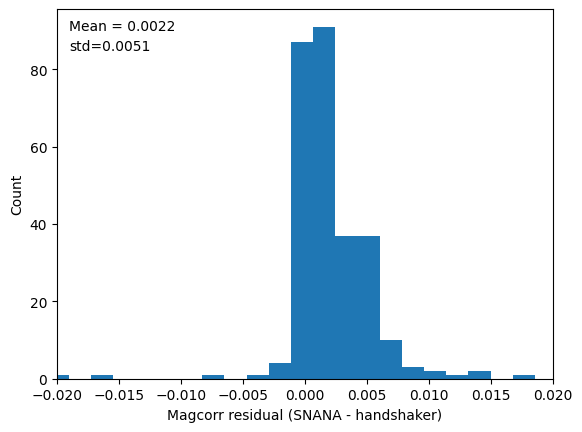

In [ ]:
comparison = comparison[comparison["residual"] < 0.2]
plt.hist(comparison["residual"], bins=40)
plt.xlabel("Magcorr residual (SNANA - handshaker)")
plt.text(-0.019, 90, f"Mean = {comparison['residual'].mean():.4f}")
plt.text(-0.019, 85, f"std={comparison['residual'].std():.4f}")

plt.xlim(-0.02, 0.02)
plt.ylabel("Count")

plt.savefig("magcor_residuals.png")

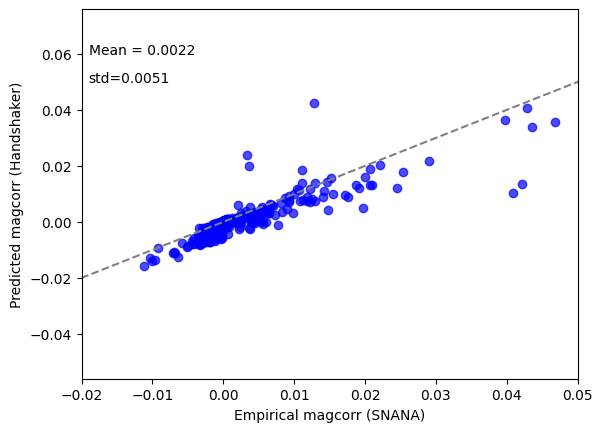

In [41]:
comparison = comparison[comparison["residual"] < 0.2]
plt.plot(comparison["empirical_delta_mag"], comparison["predicted_delta_mag"], ls="", marker="o", color="blue", alpha=0.7)
x = np.linspace(-0.05, 0.07, 1000)
y = x
plt.plot(x, y, ls="--", color="grey")
plt.xlabel("Magcorr residual (SNANA - handshaker)")

plt.text(-0.019, 0.06, f"Mean = {comparison['residual'].mean():.4f}")
plt.text(-0.019, 0.05, f"std={comparison['residual'].std():.4f}")


plt.xlim(-.02, 0.05)
plt.ylabel("Predicted magcorr (Handshaker)")
plt.xlabel("Empirical magcorr (SNANA)")
plt.savefig("handshaker_snana_scatter.png")